# Task 2: Quantitative Analysis using pandas-ta and PyNance

In [1]:
import pandas as pd
import yfinance as yf
import pandas_ta as ta
import matplotlib.pyplot as plt
import os
import glob

# Ensure data directory exists
data_dir = '../data/raw'
stock_files = glob.glob(os.path.join(data_dir, '*.csv'))
stock_files = [f for f in stock_files if 'raw_analyst_ratings' not in f]

print("Found stock files:", stock_files)

Found stock files: ['../data/raw\\AAPL.csv', '../data/raw\\AMZN.csv', '../data/raw\\GOOG.csv', '../data/raw\\META.csv', '../data/raw\\NVDA.csv']


## 1. Load Data

In [2]:
# Load the stock data into a dictionary
stocks = {}
for file in stock_files:
    ticker = os.path.basename(file).split('.')[0]
    df = pd.read_csv(file)
    # yfinance data usually has Date as the first column
    # The columns should be Open, High, Low, Close, Volume, etc.
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'], utc=True)
        df.set_index('Date', inplace=True)
    elif 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'], utc=True)
        df.set_index('date', inplace=True)
    
    # Sort index to ensure chronological order
    df.sort_index(inplace=True)
    
    stocks[ticker] = df

# Check AAPL data as an example
print(stocks['AAPL'].head())
print(stocks['AAPL'].info())

                              Close      High       Low      Open      Volume
Date                                                                         
2009-01-02 00:00:00+00:00  2.721686  2.730385  2.554037  2.575630   746015200
2009-01-05 00:00:00+00:00  2.836553  2.884539  2.780469  2.794266  1181608400
2009-01-06 00:00:00+00:00  2.789767  2.914229  2.770872  2.877641  1289310400
2009-01-07 00:00:00+00:00  2.729484  2.774170  2.706990  2.753477   753048800
2009-01-08 00:00:00+00:00  2.780169  2.793666  2.700393  2.712090   673500800
<class 'pandas.DataFrame'>
DatetimeIndex: 3774 entries, 2009-01-02 00:00:00+00:00 to 2023-12-29 00:00:00+00:00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   3774 non-null   float64
 1   High    3774 non-null   float64
 2   Low     3774 non-null   float64
 3   Open    3774 non-null   float64
 4   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 176.9 KB


## 2. Compute Technical Indicators with pandas-ta

In [3]:
# We will calculate SMA, EMA, RSI, and MACD for each stock
for ticker, df in stocks.items():
    # Make sure we have the right column names, pandas-ta usually expects lowercase open, high, low, close or matching strings
    # We will pass the specific columns to avoid errors
    
    # Simple Moving Average (SMA)
    df['SMA_20'] = ta.sma(df['Close'], length=20)
    
    # Exponential Moving Average (EMA)
    df['EMA_20'] = ta.ema(df['Close'], length=20)
    
    # Relative Strength Index (RSI)
    df['RSI_14'] = ta.rsi(df['Close'], length=14)
    
    # Moving Average Convergence Divergence (MACD)
    macd = ta.macd(df['Close'], fast=12, slow=26, signal=9)
    # The MACD columns are usually: MACD_12_26_9, MACDh_12_26_9, MACDs_12_26_9
    df = pd.concat([df, macd], axis=1)
    
    stocks[ticker] = df

print("Columns added to AAPL:", stocks['AAPL'].columns)

Columns added to AAPL: Index(['Close', 'High', 'Low', 'Open', 'Volume', 'SMA_20', 'EMA_20', 'RSI_14',
       'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9'],
      dtype='str')


## 3. Financial Metrics using PyNance\nNote: `pynance` offers financial metric computation. If `pynance` fails on the latest pandas versions, we calculate the daily return standard deviation or sharpe proxy manually.

In [4]:
for ticker, df in stocks.items():
    # Daily returns
    df['Daily_Return'] = df['Close'].pct_change() * 100
    
    # Calculate daily return standard deviation manually instead of using pynance
    std_dev = df['Daily_Return'].std()
    if ticker == 'AAPL':
        print(f"AAPL Daily Return Std Dev: {std_dev}")

AAPL Daily Return Std Dev: 1.8010113628161184


## 4. Visualize the Data
We visualize AAPL closing prices, moving averages, RSI, and MACD.

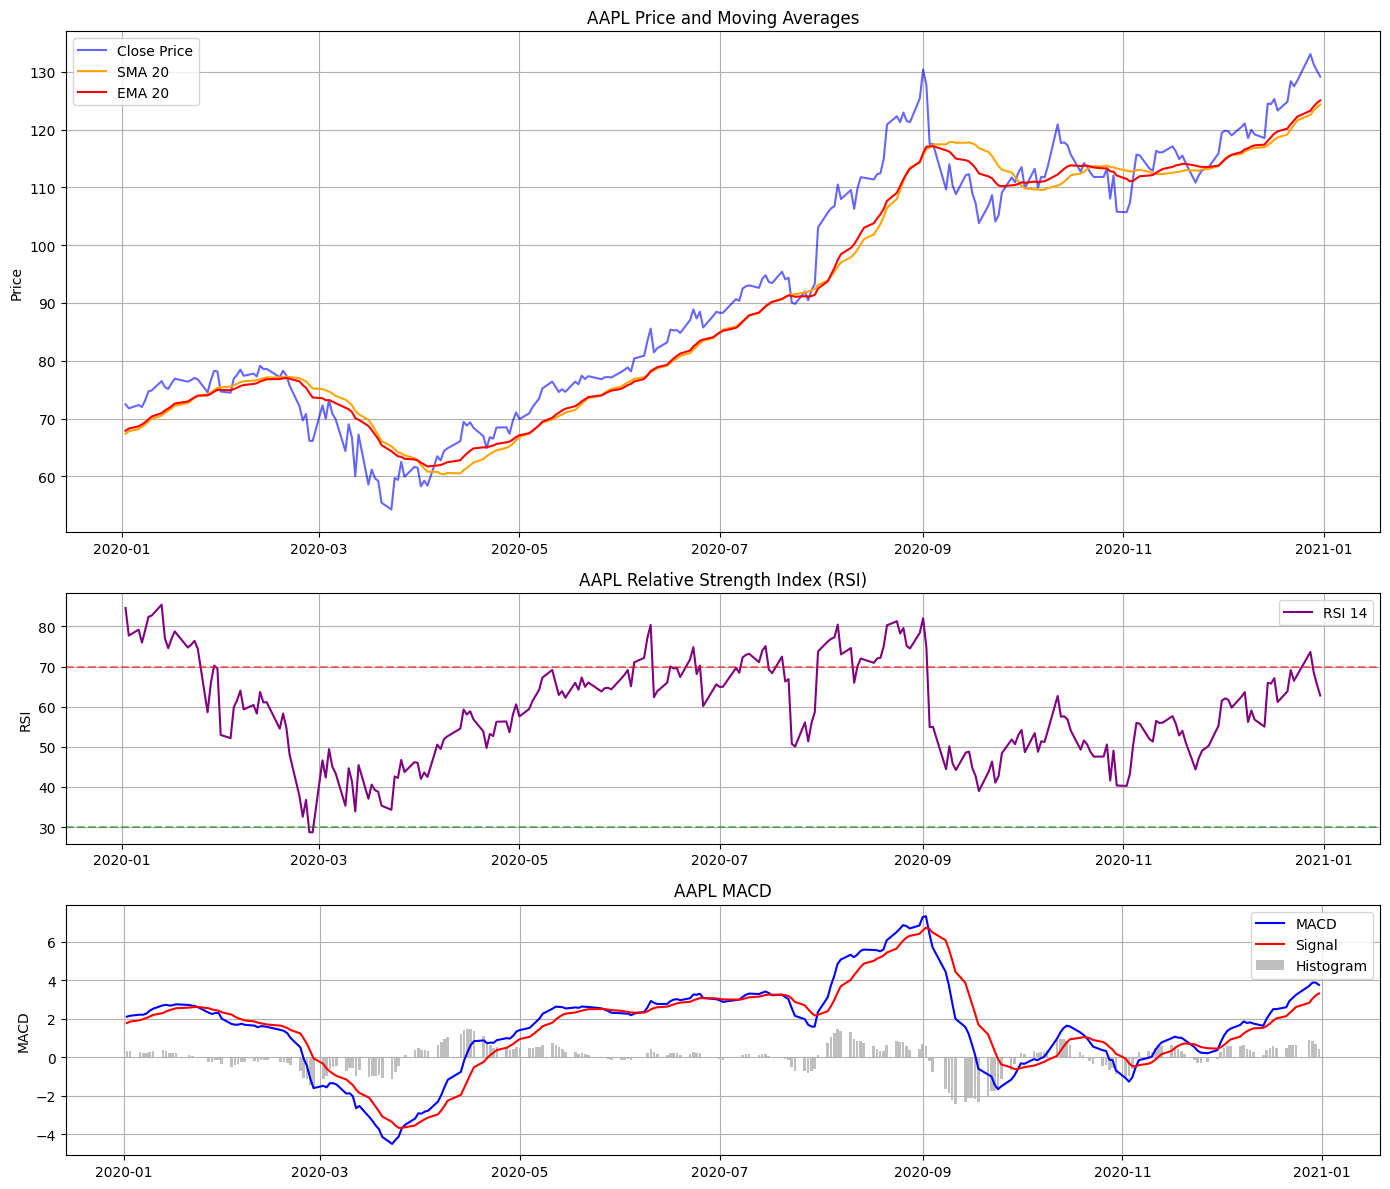

In [5]:
ticker_to_plot = 'AAPL'
df_plot = stocks[ticker_to_plot].loc['2020-01-01':'2021-01-01']  # Use 2020 data to match the high volume period in EDA

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), gridspec_kw={'height_ratios': [2, 1, 1]})

# Price and MAs
ax1.plot(df_plot.index, df_plot['Close'], label='Close Price', color='blue', alpha=0.6)
ax1.plot(df_plot.index, df_plot['SMA_20'], label='SMA 20', color='orange')
ax1.plot(df_plot.index, df_plot['EMA_20'], label='EMA 20', color='red')
ax1.set_title(f'{ticker_to_plot} Price and Moving Averages')
ax1.set_ylabel('Price')
ax1.legend()
ax1.grid()

# RSI
ax2.plot(df_plot.index, df_plot['RSI_14'], label='RSI 14', color='purple')
ax2.axhline(70, color='red', linestyle='--', alpha=0.5)
ax2.axhline(30, color='green', linestyle='--', alpha=0.5)
ax2.set_title(f'{ticker_to_plot} Relative Strength Index (RSI)')
ax2.set_ylabel('RSI')
ax2.legend()
ax2.grid()

# MACD
macd_col = [c for c in df_plot.columns if 'MACD_' in c][0]
signal_col = [c for c in df_plot.columns if 'MACDs_' in c][0]
hist_col = [c for c in df_plot.columns if 'MACDh_' in c][0]

ax3.plot(df_plot.index, df_plot[macd_col], label='MACD', color='blue')
ax3.plot(df_plot.index, df_plot[signal_col], label='Signal', color='red')
ax3.bar(df_plot.index, df_plot[hist_col], label='Histogram', color='gray', alpha=0.5)
ax3.set_title(f'{ticker_to_plot} MACD')
ax3.set_ylabel('MACD')
ax3.legend()
ax3.grid()

plt.tight_layout()
plt.show()